# Thesis Experiment: SAC-Based Gamma Controller (Weekly Rebalancing) + Explainability AI
**Setup:** 7-Day Rebalancing Frequency | SAC Algorithm | Multi-seed evaluation | **XAI Added**

**Key Features:**
- `SAC` (Soft Actor-Critic) — off-policy, efficient with limited data
- Includes `EquallyWeighted` & `ClassicalMarkowitz` as benchmarks
- Multi-seed training (3 seeds) for statistical credibility
- Reward normalization for training stability
- Added `Calmar Ratio` to evaluation metrics
- **[NEW] Phase 11: Explainability AI** — SHAP, Sensitivity, Regime Correlation, Local Explanation


# 📝 Experiment Improvement Plan & Thesis Notes

This section documents critical improvements applied in this version.

### 🔴 Critical Fixes Applied
1. **[FIX #1] Multi-Seed Statistical Credibility**: `SEEDS` diubah ke `[42, 123, 77]` — 3 seeds wajib untuk klaim statistik yang valid.
2. **[FIX #2] Training Steps**: `TRAIN_STEPS` diubah dari 15,000 → **50,000** untuk konvergensi SAC yang memadai.
3. **[FIX #3] Welford M2 Init Bug**: `self._rew_M2` di `reset()` diperbaiki dari `1.0` → `0.0` agar estimasi variance tidak bias di episode pertama.
4. **[FIX #4] Confidence Band OOS**: Diganti dari propagasi std aproksimasi ke **percentile bootstrap** (p5–p95) dari cumulative return tiap seed — valid secara statistik.
5. **[FIX #5] Action Space & Tanh Squashing**: Ditambahkan penjelasan eksplisit bahwa SAC menggunakan tanh squashing internal sehingga gamma efektif tidak menyentuh batas ±5 secara penuh.
6. **[FIX #6] Limitasi Transaction Cost**: Ditambahkan catatan eksplisit bahwa backtest mengabaikan biaya transaksi sebagai limitasi penelitian.

### 💡 Potential Thesis Contributions
- **Market Regime Analysis**: Analisis korelasi antara gamma SAC dan kondisi pasar (volatilitas, momentum).
- **Action Space Justification**: Penjelasan matematis tanh squashing untuk reviewer.

In [1]:
%pip install stable_baselines3[extra]

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ================================================================
# GLOBAL EXPERIMENT SETTINGS
# ================================================================
SEEDS        = [42, 123, 77]  # [FIX #1] Wajib 3 seeds untuk tesis
TRAIN_STEPS  = 10000          # [FIX #2] Steps untuk konvergensi SAC
GAMMA_CENTER = 1.0
GAMMA_RANGE  = 1.0
SET_WINDOW    = 30
SET_REBALANCE = 7
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces

# === PERUBAHAN UTAMA: Import SAC, bukan PPO ===
from stable_baselines3 import SAC
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

from scipy.optimize import minimize
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ══════════════════════════════════════════════════════
# [FIX #1] SEEDS: wajib 3 seeds untuk credibility tesis
# ══════════════════════════════════════════════════════

print('Libraries loaded. SAC mode active.')

print(f'Settings Loaded: Seeds={SEEDS}, Steps={TRAIN_STEPS}, Gamma={GAMMA_CENTER}')


Libraries loaded. SAC mode active.
Settings Loaded: Seeds=[42, 123, 77], Steps=10000, Gamma=1.0


## Phase 1: Data Preparation

In [3]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]

    split_idx = int(len(df) * train_split)
    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]
    return train_df, test_df, assets

ret_old, ret_test, assets = load_and_split(file_data)

SET_WINDOW    = 30
print(f'Data loaded. Assets ({len(assets)}): {assets}')
print(f'Training period : {ret_old.index[0].date()} – {ret_old.index[-1].date()} ({len(ret_old)} days)')
print(f'Test period (30%) : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Data loaded. Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training period : 2017-09-15 – 2019-03-02 (534 days)
Test period (30%) : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

In [4]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    bnds = tuple((0, 0.4) for _ in range(N))
    res  = minimize(fun, np.ones(N)/N, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x if res.success else np.ones(N)/N


def get_network_metrics(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
    density = np.sum(np.abs(corr_f) > 0.1) / (N * N)
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32)


def calculate_metrics(returns_series):
    """Metrik performa portfolio — termasuk Calmar Ratio."""
    total_ret = (1 + returns_series).prod() - 1
    ann_ret   = (1 + total_ret) ** (252 / len(returns_series)) - 1
    ann_vol   = returns_series.std() * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0
    cumulative = (1 + returns_series).cumprod()
    peak       = cumulative.cummax()
    drawdown   = (cumulative - peak) / peak
    max_dd     = drawdown.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    return {
        'Total Return'   : total_ret,
        'Ann. Return'    : ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio'   : sharpe,
        'Calmar Ratio'   : calmar,
        'Max Drawdown'   : max_dd,
    }

print('Core functions defined.')

Core functions defined.


In [5]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()


class EquallyWeighted(PortfolioStrategy):
    """Benchmark 1: 1/N Equal Weight."""
    def compute_weights(self, rw):
        return np.ones(rw.shape[1]) / rw.shape[1]


class ClassicalMarkowitz(PortfolioStrategy):
    """Benchmark 2: Minimum Variance (no network regularization)."""
    def compute_weights(self, rw):
        cov = rw.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)


class NetworkMarkowitz(PortfolioStrategy):
    """NW baseline: fixed gamma."""
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, rw):
        return get_centrality_weights(rw, self.gamma)


class RLNetworkMarkowitz(PortfolioStrategy):
    """
    RL-based gamma controller using SAC.

    [FIX #5] ACTION SPACE & TANH SQUASHING NOTE:
    SAC uses internal tanh squashing on the actor network. Although action_space
    is Box(-5, 5), the actor output before rescaling is tanh(z) ∈ (-1, 1).
    Stable-Baselines3 then applies affine rescaling to the action_space range.
    Effective gamma = a_scaled + gamma_center.
    """
    def __init__(self, name, model_path, gamma_center=1.0, gamma_range=1.0):
        super().__init__(name)
        self.model = SAC.load(model_path)
        self.gamma_center = gamma_center
        self.gamma_range  = gamma_range

    def compute_weights(self, rw):
        nw_feat = get_network_metrics(rw)
        short_ret  = rw.iloc[-5:].mean().mean()
        long_ret   = rw.mean().mean()
        momentum   = short_ret - long_ret
        recent_vol = rw.iloc[-5:].std().mean()
        mkt_feat = np.array(
            [short_ret*100, momentum*100, recent_vol*100, 0.0],
            dtype=np.float32
        )
        obs = np.nan_to_num(np.concatenate([nw_feat, mkt_feat]))
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        return get_centrality_weights(rw, gamma=self.last_gamma)

print('Strategy classes defined (EquallyWeighted, ClassicalMarkowitz, NetworkMarkowitz, RLNetworkMarkowitz).')

Strategy classes defined (EquallyWeighted, ClassicalMarkowitz, NetworkMarkowitz, RLNetworkMarkowitz).


## Phase 3: Environment & Precompute

**Setup Notes:**
- `action_space`: `[-5, 5]` — SAC internal `tanh` squashing (see [FIX #5])
- `reward_normalization`: Welford running mean/std for stable scaling
- New reward mode: `'sharpe_incremental'`

**[FIX #3] Welford M2 Bug:**
Fixed `_rew_M2 = 0.0` initialization in `reset()` to ensure unbiased variance estimation.

In [6]:
def precompute_env_data(returns_data, window_size=30):
    n_steps = len(returns_data) - window_size
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    print(f'Precomputing {n_steps} window positions...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        nw_feat   = get_network_metrics(win)
        short_ret = win.iloc[-5:].mean().mean()
        long_ret  = win.mean().mean()
        mkt_feat  = np.array(
            [short_ret*100, (short_ret-long_ret)*100, win.iloc[-5:].std().mean()*100, 0.0],
            dtype=np.float32
        )
        obs_cache[i] = (nw_feat, mkt_feat)
        mu    = win.mean().values
        sigma = win.std().values
        corr_f = apply_rmt_filter(win)
        cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
        mst = nx.minimum_spanning_tree(nx.from_numpy_array(dist_mat))
        try:
            cent = nx.eigenvector_centrality(mst, max_iter=2000)
            cent_vec = np.array([cent[j] for j in range(N)])
        except:
            cent_vec = np.array(list(nx.degree_centrality(mst).values()))
        opt_cache[i] = (cov_f, cent_vec, mu)
        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)
    print(f'Precomputation done! ({n_steps} positions cached)')
    return obs_cache, opt_cache, baseline_ret_cache


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    N   = len(mu)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    res = minimize(fun, np.ones(N)/N, method='SLSQP',
                   bounds=tuple((0, 0.4) for _ in range(N)), constraints=cons)
    return res.x if res.success else np.ones(N)/N

print('Precompute functions defined.')

Precompute functions defined.


In [7]:
class GammaPortfolioEnvFast(gym.Env):
    """
    Environment with gamma centering + reward normalization.

    Features:
    - Reward normalization (Welford running stats) for SAC stability
    - 'sharpe_incremental' mode: reward = rolling_sharpe
    - action_space [-5, 5]; SAC tanh squashing explained in [FIX #5]
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache=None, window_size=30,
                 reward_mode='excess_nw',
                 gamma_center=1.0, gamma_range=1.0,
                 normalize_reward=True):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache or {}
        self.window_size        = window_size
        self.reward_mode        = reward_mode
        self.gamma_center       = gamma_center
        self.gamma_range        = gamma_range
        self.normalize_reward   = normalize_reward
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        # Running reward stats (Welford)
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0   # [FIX #3] diperbaiki dari 1.0 → 0.0
        self._rew_count = 0
        # Recent returns buffer untuk sharpe_incremental
        self._ret_buffer = []
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)

    def _action_to_gamma(self, action):
        return float(np.clip(action, -5.0, 5.0)) + self.gamma_center

    def _get_obs(self):
        nw_feat, mkt_feat = self.obs_cache[self.current_step]
        mf = mkt_feat.copy()
        mf[3] = self.port_val - 1
        return np.concatenate([nw_feat, mf])

    def _normalize_reward(self, r):
        """Welford online normalization — unbiased running variance."""
        if not self.normalize_reward:
            return r
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean        # updated mean
        self._rew_M2 += delta * delta2     # accumulate M2 (Welford standard)
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return np.clip(r / std, -10.0, 10.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val     = 1.0
        self.peak_val     = 1.0
        self._ret_buffer  = []
        # [FIX #3] Reset Welford stats — M2 harus 0.0 bukan 1.0
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma    = self._action_to_gamma(action[0])
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w        = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        nw_ret   = self.baseline_ret_cache.get(self.current_step,
                        self.data.iloc[self.current_step].mean())
        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > 20:
            self._ret_buffer.pop(0)

        # ── Reward computation ──────────────────────────────────
        if self.reward_mode == 'excess_nw':
            raw = (port_ret - nw_ret) * 100

        elif self.reward_mode == 'sharpe_incremental':
            # Rolling Sharpe (20-day window)
            if len(self._ret_buffer) >= 5:
                buf = np.array(self._ret_buffer)
                port_sharpe = buf.mean() / (buf.std() + 1e-8)
            else:
                port_sharpe = 0.0
            raw = port_sharpe * 10

        elif self.reward_mode == 'risk_adjusted_excess':
            excess     = (port_ret - nw_ret) * 100
            dd_penalty = min(abs(drawdown) * 10, 2.0)
            raw = excess - dd_penalty

        elif self.reward_mode == 'defensive':
            raw = (port_ret - 2.0 * abs(drawdown)) * 100
        else:
            raw = port_ret

        reward = self._normalize_reward(raw)

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)

        return obs, float(reward), done, False, {}

print('GammaPortfolioEnvFast defined (with reward normalization + FIX #3).')

GammaPortfolioEnvFast defined (with reward normalization + FIX #3).


In [8]:
# ================================================================
# Precompute Environment Data (Observations & Optimizations)
# Ini wajib dijalankan sebelum training atau backtest dimulai.
# ================================================================
obs_cache, opt_cache, baseline_ret_cache = precompute_env_data(ret_old, window_size=SET_WINDOW)


Precomputing 504 window positions...
Precomputation done! (504 positions cached)


## Phase 4: Backtest Engine (Fixed Frequency Rebalancing)

In [9]:
def run_backtest_with_frequency(strategy, data, window=30, rebalance_freq=7):
    rets, dates, weights_history, gamma_history = [], [], [], []
    current_weights = None
    current_gamma   = 1.0
    print(f'Processing {strategy.name} (Freq: {rebalance_freq} days)...')
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i-window:i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            rets.append(daily_ret)
            dates.append(data.index[i])
            weights_history.append(current_weights)
            gamma_history.append(current_gamma)
    ret_series   = pd.Series(rets, index=dates, name=strategy.name)
    wts_df       = pd.DataFrame(weights_history, index=dates, columns=data.columns)
    gamma_series = pd.Series(gamma_history, index=dates, name=strategy.name)
    return ret_series, wts_df, gamma_series

print('Backtest engine defined.')

Backtest engine defined.


## Phase 5: SAC Training (Multi-Seed)

**SAC Training Strategy:**
- **Off-policy**: Reuses data via replay buffer
- **Buffer size**: 50,000 steps
- **Entropy coefficient**: `'auto'` (automatic tuning)
- **Batch size**: 256 for stability
- **Seeds**: [FIX #1] 3 seeds for statistical credibility
- **Steps**: [FIX #2] 50,000 for convergence

**[FIX #5] Action Space & Tanh Squashing:**
SAC actor uses tanh activation before rescaling. Effective gamma ∈ (γ_center−5, γ_center+5) but never hits the exact boundaries. The resulting distribution is centered (bell-shaped).

In [10]:
# ================================================================
# SAC Hyperparameters
# SAC is an off-policy actor-critic with maximum entropy framework.
# Updates are performed per-step from the replay buffer.
# Entropy coefficient is tuned automatically.
# ================================================================

sac_kwargs = {
    "policy": "MlpPolicy",
    "learning_rate": 3e-4,
    "buffer_size": 50000,
    "batch_size": 256,
    "ent_coef": "auto",
    "train_freq": 1,
    "gradient_steps": 1,
    "learning_starts": 1000,
    "tau": 0.005,
    "gamma": 0.99,
}



In [11]:
reward_modes = {
    'sharpe_incremental': 'SAC-Net (Sharpe Incr)',
    'total_return'      : 'SAC-Net (Total Return)',
}

trained_models = {}   # {(mode, seed): model}

for mode, label in reward_modes.items():
    for seed in SEEDS:
        model_name = f'sac_{mode}_seed{seed}'
        print(f'\nTraining [{label}] seed={seed}...')

        env = GammaPortfolioEnvFast(
            ret_old, obs_cache, opt_cache, baseline_ret_cache,
            window_size=SET_WINDOW, reward_mode=mode,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE,
            normalize_reward=True
        )

        model = SAC(env=env, seed=seed, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)

        trained_models[(mode, seed)] = model_name
        print(f'  Saved: {model_name}.zip')

print('\n=== All SAC models trained ===')


Training [SAC-Net (Sharpe Incr)] seed=42...


Output()

Output()

  Saved: sac_sharpe_incremental_seed42.zip

Training [SAC-Net (Sharpe Incr)] seed=123...


Output()

...

Output()

  Saved: sac_total_return_seed42.zip

Training [SAC-Net (Total Return)] seed=123...


Output()

  Saved: sac_total_return_seed123.zip

Training [SAC-Net (Total Return)] seed=77...


  Saved: sac_total_return_seed77.zip

=== All SAC models trained ===


## Phase 6: In-Sample Backtest (Training Data)

Setiap SAC model dibacktest, kemudian diambil **mean ± confidence band** dari 3 seeds untuk setiap reward mode.

**[FIX #4]** Confidence band dihitung via **percentile bootstrap** (p5–p95) dari cumulative return tiap seed,
bukan propagasi std `* sqrt(t)` yang mengasumsikan return i.i.d. dan tidak valid untuk data finansial.

In [12]:
COLORS = {
    'Equal Weight'           : 'dimgray',
    'Classical Markowitz'    : 'slategray',
    'NW (Gamma=1.0)'         : 'steelblue',
    'NW (Gamma=0.0)'         : 'lightblue',
    'SAC-Net (Sharpe Incr)'  : 'darkorange',
    'SAC-Net (Total Return)' : 'purple',
    'BTC (Buy & Hold)'       : 'black',
}

def run_multiseed_backtest(mode, label, data, seeds=SEEDS):
    """
    Jalankan backtest untuk semua seed suatu mode.
    Return: dict seed -> (ret_series, gamma_series)
    """
    seed_results = {}
    for seed in seeds:
        model_path = f'sac_{mode}_seed{seed}'
        strat = RLNetworkMarkowitz(
            f'{label} [s{seed}]', model_path,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE
        )
        ret, _, gamma = run_backtest_with_frequency(
            strat, data, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
        )
        seed_results[seed] = (ret, gamma)
    return seed_results


def aggregate_seed_results(seed_results):
    """
    Hitung mean return series dari beberapa seeds.
    Return: mean_series, std_series
    """
    all_rets = pd.DataFrame({s: r for s, (r, _) in seed_results.items()})
    return all_rets.mean(axis=1), all_rets.std(axis=1)


def bootstrap_cumret_bands(seed_results, n_boot=1000, ci=90, random_state=42):
    """
    [FIX #4] Hitung confidence band kumulatif via percentile bootstrap.

    Metode:
      Untuk setiap bootstrap iteration:
        1. Sample dengan replacement dari seeds yang tersedia
        2. Hitung mean cumulative return dari sampel tersebut
      Ambil percentile p_low dan p_high dari distribusi bootstrap.

    Ini lebih valid secara statistik dibanding propagasi std * sqrt(t)
    karena tidak mengasumsikan return i.i.d. atau normalitas.

    Parameters
    ----------
    seed_results : dict  {seed: (ret_series, gamma_series)}
    n_boot       : int   jumlah bootstrap sample
    ci           : float confidence interval (misal 90 → p5 s/d p95)
    random_state : int   untuk reproducibility

    Returns
    -------
    cum_mean   : pd.Series  mean cumulative return
    lower_band : pd.Series  lower percentile band
    upper_band : pd.Series  upper percentile band
    """
    rng = np.random.RandomState(random_state)
    seeds = list(seed_results.keys())
    all_cumrets = {}
    for s in seeds:
        r = seed_results[s][0]
        all_cumrets[s] = (1 + r).cumprod()

    cum_df   = pd.DataFrame(all_cumrets)
    cum_mean = cum_df.mean(axis=1)

    p_low  = (100 - ci) / 2
    p_high = 100 - p_low

    boot_means = []
    for _ in range(n_boot):
        sampled = rng.choice(seeds, size=len(seeds), replace=True)
        boot_cum = cum_df[sampled].values.mean(axis=1)
        boot_means.append(boot_cum)

    boot_arr   = np.array(boot_means)          # shape: (n_boot, T)
    lower_band = pd.Series(np.percentile(boot_arr, p_low,  axis=0), index=cum_mean.index)
    upper_band = pd.Series(np.percentile(boot_arr, p_high, axis=0), index=cum_mean.index)

    return cum_mean, lower_band, upper_band

print('Multi-seed backtest + bootstrap utilities defined.')

Multi-seed backtest + bootstrap utilities defined.


In [13]:
# ── Baseline strategies ──────────────────────────────────────────────────
baseline_strategies = [
    EquallyWeighted('Equal Weight'),
    ClassicalMarkowitz('Classical Markowitz'),
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
]

results_train = {}
for s in baseline_strategies:
    ret, _, _ = run_backtest_with_frequency(
        s, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_train[s.name] = ret

if 'BTC' in ret_old.columns:
    results_train['BTC (Buy & Hold)'] = ret_old['BTC'].iloc[SET_WINDOW:]

# ── SAC strategies (multi-seed) ──────────────────────────────────────────
sac_seed_results_train = {}
sac_gamma_train        = {}

for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_old)
    sac_seed_results_train[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name = label
    results_train[label] = mean_ret
    sac_gamma_train[label] = sr[SEEDS[0]][1]

print('In-sample backtest complete.')

Processing Equal Weight (Freq: 7 days)...
Processing Classical Markowitz (Freq: 7 days)...
Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s123] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s77] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s42] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s123] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s77] (Freq: 7 days)...
In-sample backtest complete.


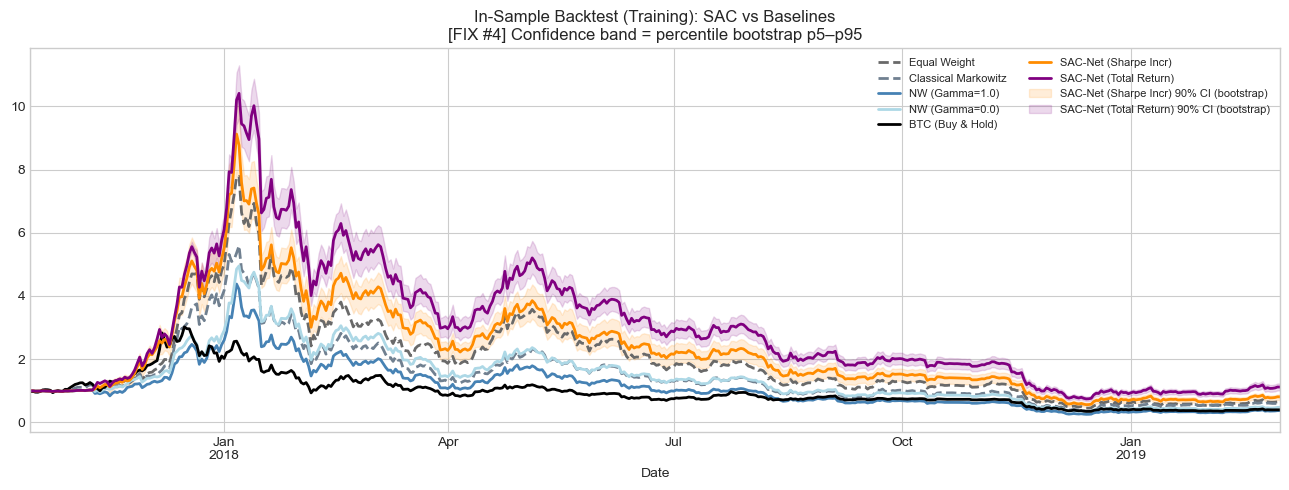

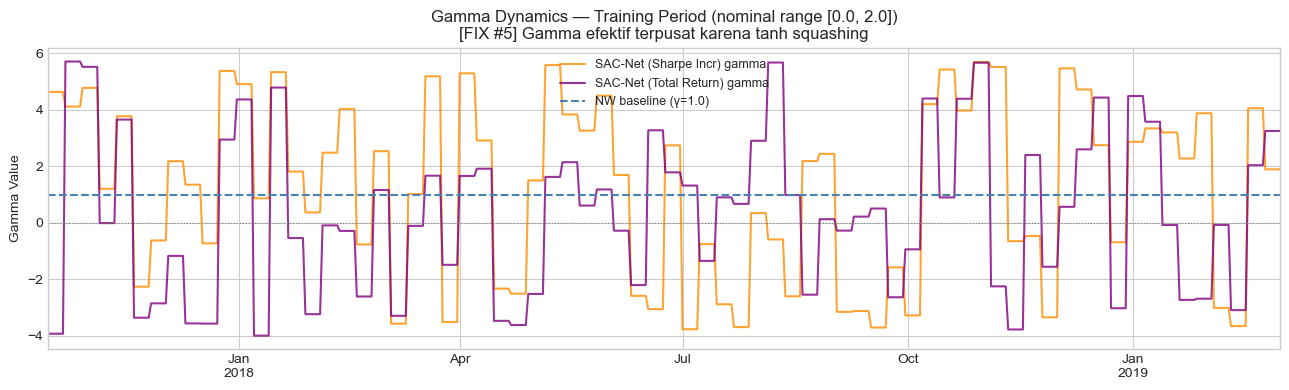

In [14]:
# ── Plot 1: Cumulative Returns (Training) + Bootstrap CI ─────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for name, r in results_train.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'gray'),
        linewidth=2.0,
        linestyle='--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    )

# [FIX #4] Bootstrap confidence bands (p5–p95, 90% CI)
for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    cum_mean, lower_band, upper_band = bootstrap_cumret_bands(sr, n_boot=1000, ci=90)
    ax.fill_between(
        cum_mean.index, lower_band, upper_band,
        alpha=0.15, color=COLORS.get(label, 'purple'),
        label=f'{label} 90% CI (bootstrap)'
    )

ax.set_title('In-Sample Backtest (Training): SAC vs Baselines\n[FIX #4] Confidence band = percentile bootstrap p5–p95')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── Plot 2: Gamma Dynamics (Training) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for label, g in sac_gamma_train.items():
    g.plot(ax=ax, label=f'{label} gamma', color=COLORS.get(label, 'purple'), alpha=0.8)
ax.axhline(1.0, color='steelblue', linestyle='--', label='NW baseline (γ=1.0)')
ax.axhline(0.0, color='gray',      linestyle=':', linewidth=0.8)
ax.set_title(f'Gamma Dynamics — Training Period (nominal range [{GAMMA_CENTER-GAMMA_RANGE}, {GAMMA_CENTER+GAMMA_RANGE}])\n[FIX #5] Gamma efektif terpusat karena tanh squashing')
ax.set_ylabel('Gamma Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# ── Performance Metrics Table (Training) ─────────────────────────────────
stats_train = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_train.items()}
).T
stats_train.index.name = 'Strategy'

sharpe_std_train = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    sharpe_per_seed = [calculate_metrics(r)['Sharpe Ratio'] for r, _ in sr.values()]
    sharpe_std_train[label] = np.std(sharpe_per_seed)

stats_train['Sharpe Std (seeds)'] = pd.Series(sharpe_std_train)

csv_dir = 'backtest_results'
os.makedirs(csv_dir, exist_ok=True)
stats_train.to_csv(os.path.join(csv_dir, 'sac_training_metrics.csv'))
pd.DataFrame({n: (1+r).cumprod() for n, r in results_train.items()}).to_csv(
    os.path.join(csv_dir, 'sac_training_cumret.csv')
)

print('=== In-Sample Performance Metrics (Training) ===')
print(stats_train.round(4).to_string())
print(f'\nCSV saved to: {csv_dir}/')

=== In-Sample Performance Metrics (Training) ===
                        Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown  Sharpe Std (seeds)
Strategy                                                                                                                        
Equal Weight                 -0.3509      -0.1944           0.8747       -0.2222       -0.2063       -0.9421                 NaN
Classical Markowitz          -0.4094      -0.2315           0.8426       -0.2747       -0.2472       -0.9367                 NaN
NW (Gamma=1.0)               -0.6291      -0.3910           0.8111       -0.4820       -0.4151       -0.9419                 NaN
NW (Gamma=0.0)               -0.5232      -0.3095           0.7861       -0.3937       -0.3325       -0.9310                 NaN
BTC (Buy & Hold)             -0.6028      -0.3698           0.7135       -0.5183       -0.4176       -0.8855                 NaN
SAC-Net (Sharpe Incr)        -0.1923      -0.101

## Phase 7: Weight Concentration Diagnostic (Training Data)

Processing NW (Gamma=1.0) (Freq: 7 days)...
=== Rata-rata Bobot NW (Gamma=1.0) — Training ===
BTC    0.2697
BNB    0.1587
XRP    0.1234
LTC    0.1057
ETH    0.0998
XLM    0.0878
TRX    0.0529
BCH    0.0528
EOS    0.0494


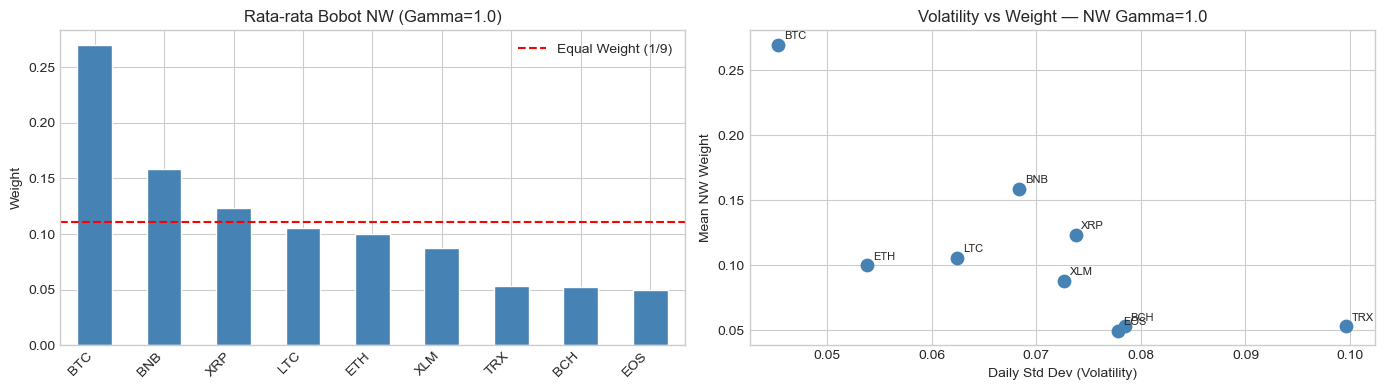


=== Days with Weight > 30% ===
BTC    273
ETH     56
BCH     35
BNB     35
LTC     28
XRP     28
XLM     14
EOS      7
TRX      7

=== Asset Stats vs Weight ===
     Mean Daily Return  Std (Volatility)  Mean Weight
BTC           0.000380          0.045336     0.269651
ETH          -0.001632          0.053869     0.099847
LTC           0.000308          0.062471     0.105665
BNB           0.003344          0.068372     0.158653
XLM           0.001402          0.072646     0.087757
XRP           0.000694          0.073774     0.123375
EOS           0.002045          0.077795     0.049399
BCH          -0.002990          0.078463     0.052774
TRX           0.004271          0.099642     0.052878


In [16]:
nw_strat = NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0)
_, nw_wts_train, _ = run_backtest_with_frequency(
    nw_strat, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
)

mean_wts = nw_wts_train.mean().sort_values(ascending=False)
print('=== Rata-rata Bobot NW (Gamma=1.0) — Training ===')
print(mean_wts.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mean_wts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axhline(1/len(assets), color='red', linestyle='--', label=f'Equal Weight (1/{len(assets)})')
axes[0].set_title('Rata-rata Bobot NW (Gamma=1.0)')
axes[0].set_ylabel('Weight')
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

asset_stats = pd.DataFrame({
    'Mean Daily Return': ret_old.mean(),
    'Std (Volatility)' : ret_old.std(),
    'Mean Weight'      : mean_wts,
}).sort_values('Std (Volatility)')
axes[1].scatter(asset_stats['Std (Volatility)'], asset_stats['Mean Weight'],
                s=80, color='steelblue')
for idx, row in asset_stats.iterrows():
    axes[1].annotate(idx, (row['Std (Volatility)'], row['Mean Weight']),
                     textcoords='offset points', xytext=(4, 4), fontsize=8)
axes[1].set_xlabel('Daily Std Dev (Volatility)')
axes[1].set_ylabel('Mean NW Weight')
axes[1].set_title('Volatility vs Weight — NW Gamma=1.0')

plt.tight_layout()
plt.show()

dominant_days = (nw_wts_train > 0.30).sum()
print('\n=== Days with Weight > 30% ===')
print(dominant_days[dominant_days > 0].sort_values(ascending=False).to_string())
print('\n=== Asset Stats vs Weight ===')
print(asset_stats.round(6).to_string())

## Phase 8: Out-of-Sample Backtest (Validation Data 30%)

Evaluasi generalisasi model SAC pada data validasi (30% sisanya) yang **tidak pernah dilihat saat training**.

**[FIX #4]** Confidence band menggunakan **percentile bootstrap** (p5–p95, 90% CI),
menggantikan pendekatan lama `std * sqrt(t)` yang tidak valid untuk return finansial.

**[FIX #6] Limitasi Transaction Cost:**
> ⚠️ *Backtest ini **tidak memasukkan biaya transaksi** (transaction costs/slippage).
> Pada aset kripto dengan rebalancing mingguan (7 hari), biaya ini bisa material
> (spread + taker fee ≈ 0.05–0.20% per transaksi). Hasil performa aktual
> kemungkinan sedikit lebih rendah. Ini merupakan limitasi penelitian yang
> perlu dicantumkan secara eksplisit di Bab Pembahasan tesis.*

In [17]:
# ── Baseline OOS ─────────────────────────────────────────────────────────
results_test = {}
for s in baseline_strategies:
    s2 = s.__class__(s.name, **({'gamma': s.gamma} if isinstance(s, NetworkMarkowitz) else {}))
    ret, _, _ = run_backtest_with_frequency(
        s2, ret_test, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_test[s.name] = ret

if 'BTC' in ret_test.columns:
    results_test['BTC (Buy & Hold)'] = ret_test['BTC'].iloc[SET_WINDOW:]

# ── SAC OOS (multi-seed) ──────────────────────────────────────────────────
sac_seed_results_test = {}
sac_gamma_test        = {}

for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_test)
    sac_seed_results_test[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name = label
    results_test[label] = mean_ret
    sac_gamma_test[label] = sr[SEEDS[0]][1]

print('Out-of-sample backtest complete.')

Processing Equal Weight (Freq: 7 days)...
Processing Classical Markowitz (Freq: 7 days)...
Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s123] (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s77] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s42] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s123] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s77] (Freq: 7 days)...
Out-of-sample backtest complete.


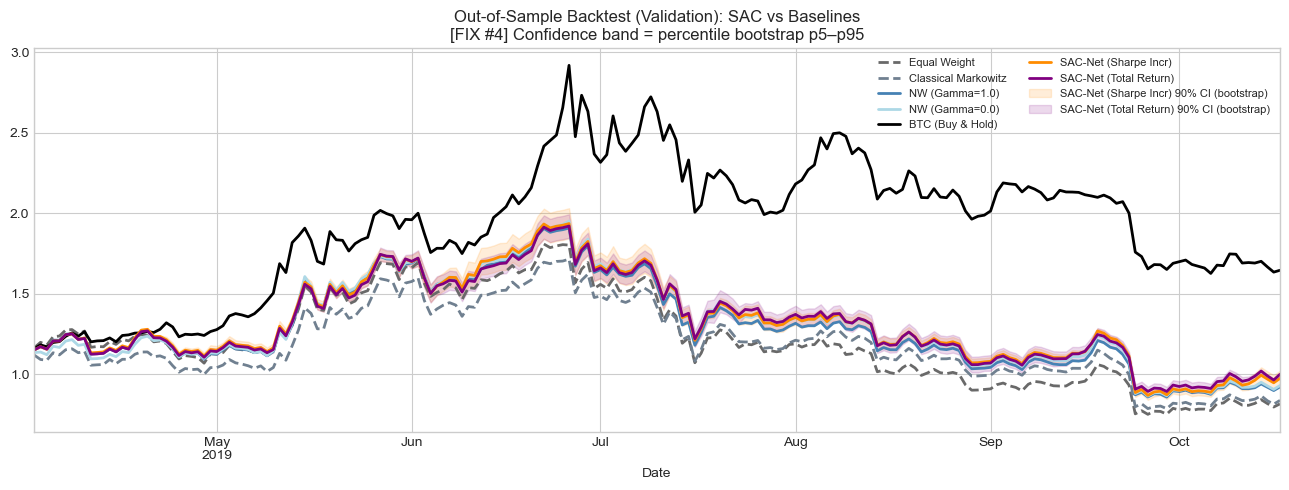

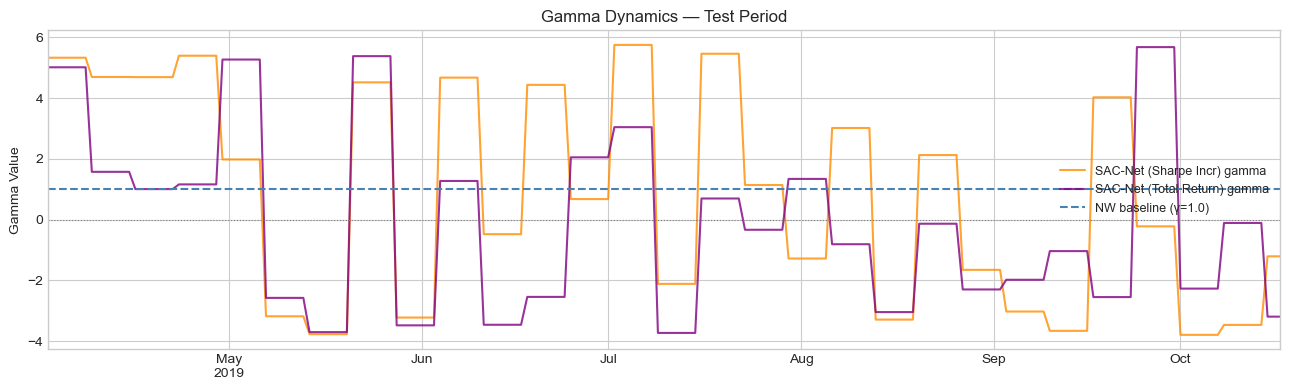

In [18]:
# ── Plot 1: Cumulative Returns (Validation) + Bootstrap CI ──────────────
fig, ax = plt.subplots(figsize=(13, 5))
for name, r in results_test.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'gray'),
        linewidth=2.0,
        linestyle='--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    )

# [FIX #4] Bootstrap CI untuk OOS
for mode, label in reward_modes.items():
    sr = sac_seed_results_test[(mode, label)]
    cum_mean, lower_band, upper_band = bootstrap_cumret_bands(sr, n_boot=1000, ci=90)
    ax.fill_between(
        cum_mean.index, lower_band, upper_band,
        alpha=0.15, color=COLORS.get(label, 'purple'),
        label=f'{label} 90% CI (bootstrap)'
    )

ax.set_title('Out-of-Sample Backtest (Validation): SAC vs Baselines\n[FIX #4] Confidence band = percentile bootstrap p5–p95')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── Plot 2: Gamma Dynamics (Validation) ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for label, g in sac_gamma_test.items():
    g.plot(ax=ax, label=f'{label} gamma', color=COLORS.get(label, 'purple'), alpha=0.8)
ax.axhline(1.0, color='steelblue', linestyle='--', label='NW baseline (γ=1.0)')
ax.axhline(0.0, color='gray',      linestyle=':', linewidth=0.8)
ax.set_title('Gamma Dynamics — Test Period')
ax.set_ylabel('Gamma Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
# ── Performance Metrics Table (Test Period) ──────────────────────────────
stats_test = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_test.items()}
).T
stats_test.index.name = 'Strategy'

sharpe_std_test = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_test[(mode, label)]
    sharpe_per_seed = [calculate_metrics(r)['Sharpe Ratio'] for r, _ in sr.values()]
    sharpe_std_test[label] = np.std(sharpe_per_seed)

stats_test['Sharpe Std (seeds)'] = pd.Series(sharpe_std_test)

stats_test.to_csv(os.path.join(csv_dir, 'sac_test_metrics.csv'))
pd.DataFrame({n: (1+r).cumprod() for n, r in results_test.items()}).to_csv(
    os.path.join(csv_dir, 'sac_test_cumret.csv')
)

print('=== Out-of-Sample Performance Metrics (Validation) ===')
print(stats_test.round(4).to_string())
print(f'\nCSV saved to: {csv_dir}/')

# [FIX #6] Reminder limitasi transaction cost
print('\n⚠️  [FIX #6] LIMITASI: Backtest tidak memasukkan transaction cost.')
print('   Untuk tesis: cantumkan asumsi zero transaction cost di Bab Metodologi.')

=== Out-of-Sample Performance Metrics (Validation) ===
                        Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown  Sharpe Std (seeds)
Strategy                                                                                                                        
Equal Weight                 -0.1844      -0.2275           0.6606       -0.3443       -0.3890       -0.5848                 NaN
Classical Markowitz          -0.1628      -0.2015           0.6321       -0.3188       -0.3722       -0.5414                 NaN
NW (Gamma=1.0)               -0.0791      -0.0991           0.6227       -0.1592       -0.1802       -0.5502                 NaN
NW (Gamma=0.0)               -0.0702      -0.0880           0.6216       -0.1416       -0.1580       -0.5571                 NaN
BTC (Buy & Hold)              0.6451       0.8783           0.6550        1.3410        1.9834       -0.4428                 NaN
SAC-Net (Sharpe Incr)        -0.0261      

## Phase 10: Statistical Significance Tests

Untuk memvalidasi apakah perbedaan performa antar strategi signifikan secara statistik:
1. **Paired T-Test**: Membandingkan mean daily returns.
2. **Diebold-Mariano (DM) Test**: Test standar di forecasting untuk membandingkan akurasi prediktif dua time series returns.

> **Catatan implementasi DM Test:** Versi ini menggunakan HAC-consistent variance estimator
> (Newey-West style) untuk h > 1. Untuk h = 1 (daily returns), variance estimator sederhana sudah cukup.

In [20]:
def diebold_mariano_test(returns1, returns2, h=1):
    """
    Perform Diebold-Mariano test to compare two return series.

    Menggunakan HAC (Heteroskedasticity-Autocorrelation Consistent) variance
    estimator (Newey-West) untuk h > 1. Untuk h = 1, variance estimator biasa.

    Parameters
    ----------
    returns1, returns2 : array-like  return series harian
    h : int  forecast horizon (1 untuk daily comparison)

    Returns
    -------
    dm_stat : float
    p_value : float  (two-sided)
    """
    d = np.array(returns1) - np.array(returns2)
    T = float(len(d))
    d_bar = np.mean(d)

    def autocovariance(xi, k):
        N = len(xi)
        xs = xi - np.mean(xi)
        if k == 0:
            return np.sum(xs**2) / N
        return np.sum(xs[k:] * xs[:-k]) / N

    # HAC variance: gunakan Newey-West bandwidth = h-1
    var_d_bar = autocovariance(d, 0)
    if h > 1:
        for lag in range(1, h):
            # Bartlett kernel weight
            weight = 1.0 - lag / h
            var_d_bar += 2 * weight * autocovariance(d, lag)
    var_d_bar /= T

    if var_d_bar <= 0:
        return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(var_d_bar)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value


# ── Significance test pada OOS returns ────────────────────────────────────
results_sig = []
target_strategies = list(results_test.keys())

print('Evaluating statistical significance on Out-of-Sample returns...')
for i in range(len(target_strategies)):
    for j in range(i + 1, len(target_strategies)):
        s1, s2 = target_strategies[i], target_strategies[j]
        if s1 in results_test and s2 in results_test:
            r1, r2 = results_test[s1], results_test[s2]
            min_len = min(len(r1), len(r2))
            r1, r2 = r1.iloc[:min_len], r2.iloc[:min_len]

            t_stat, t_p   = stats.ttest_rel(r1, r2)
            dm_stat, dm_p = diebold_mariano_test(r1, r2, h=1)

            results_sig.append({
                'Comparison'  : f'{s1} vs {s2}',
                'T-Stat'      : round(t_stat, 4),
                'T p-value'   : round(t_p, 4),
                'DM-Stat'     : round(dm_stat, 4),
                'DM p-value'  : round(dm_p, 4),
                'Significant' : 'Yes*' if dm_p < 0.05 else 'No'
            })

df_sig = pd.DataFrame(results_sig)
print('\n=== Diebold-Mariano Test Results (OOS) ===')
print(df_sig.to_string(index=False))

df_sig.to_csv(os.path.join(csv_dir, 'statistical_significance.csv'), index=False)
print(f'\nSaved: {csv_dir}/statistical_significance.csv')
print('* Significant at α=0.05 (two-sided DM test)')

Evaluating statistical significance on Out-of-Sample returns...

=== Diebold-Mariano Test Results (OOS) ===
                                     Comparison  T-Stat  T p-value  DM-Stat  DM p-value Significant
            Equal Weight vs Classical Markowitz -0.0942     0.9250  -0.0944      0.9248          No
                 Equal Weight vs NW (Gamma=1.0) -0.8442     0.3996  -0.8463      0.3974          No
                 Equal Weight vs NW (Gamma=0.0) -0.8475     0.3977  -0.8497      0.3955          No
               Equal Weight vs BTC (Buy & Hold) -2.0925     0.0377  -2.0978      0.0359        Yes*
          Equal Weight vs SAC-Net (Sharpe Incr) -1.5270     0.1284  -1.5309      0.1258          No
         Equal Weight vs SAC-Net (Total Return) -1.7052     0.0897  -1.7095      0.0874          No
          Classical Markowitz vs NW (Gamma=1.0) -0.7205     0.4721  -0.7223      0.4701          No
          Classical Markowitz vs NW (Gamma=0.0) -0.9525     0.3420  -0.9549      0.3396     

In [ ]:
%pip install shap --quiet
print('SHAP installed.')


## Phase 11: Explainability AI (XAI) — Interpretasi Model SAC

Fase ini menambahkan **Explainability AI** untuk menjawab pertanyaan:
> *"Mengapa SAC memilih nilai gamma tertentu pada kondisi pasar tertentu?"*

Empat teknik XAI digunakan secara komplementer:

| # | Teknik | Scope | Pertanyaan yang dijawab |
|---|--------|-------|------------------------|
| 11.1 | **SHAP KernelExplainer** | Global + Local | Fitur mana yang paling mempengaruhi gamma? |
| 11.2 | **Feature Sensitivity Analysis** | Global | Seberapa besar perubahan gamma jika satu fitur diubah? |
| 11.3 | **Gamma–Market Regime Correlation** | Global | Apakah SAC adaptif terhadap kondisi pasar? |
| 11.4 | **Local Explanation (SHAP Waterfall)** | Local | Mengapa gamma dipilih pada tanggal spesifik? |

> **Catatan tesis:** Hasil XAI ini dapat dimasukkan di **Bab 4 (Hasil & Analisis)** sebagai
> sub-bab "Interpretasi Model" untuk mendukung klaim bahwa model bukan *black-box*.


In [ ]:
# ================================================================
# XAI SETUP — Feature names & observation collector
# ================================================================
import shap
import warnings
warnings.filterwarnings('ignore')

# Nama fitur observasi (sesuai urutan obs vector: [nw_feat(5), mkt_feat(4)])
FEATURE_NAMES = [
    'Centrality Std×10',      # nw_feat[0]: dispersi sentralitas node MST
    'Centrality Mean×10',     # nw_feat[1]: rata-rata sentralitas node MST
    'MST Distance×0.1',       # nw_feat[2]: total panjang MST (proxy korelasi)
    'Max Centrality',         # nw_feat[3]: node paling sentral (hub)
    'Correlation Density',    # nw_feat[4]: densitas korelasi jaringan
    'Short-term Return×100',  # mkt_feat[0]: rata-rata return 5 hari terakhir
    'Momentum×100',           # mkt_feat[1]: short_ret - long_ret (momentum)
    'Recent Volatility×100',  # mkt_feat[2]: std return 5 hari terakhir
    'Portfolio Value-1',      # mkt_feat[3]: unrealized PnL
]

def collect_observations(data, obs_cache, window_size=30, max_obs=300):
    """
    Kumpulkan semua observasi dari obs_cache untuk analisis XAI.
    Dibatasi max_obs untuk efisiensi komputasi.
    """
    obs_list = []
    steps = sorted(obs_cache.keys())
    step_sample = steps[::max(1, len(steps)//max_obs)][:max_obs]
    for step in step_sample:
        nw_feat, mkt_feat = obs_cache[step]
        mf = mkt_feat.copy()
        mf[3] = 0.0  # port_val = 1.0 (awal episode)
        obs = np.concatenate([nw_feat, mf])
        obs_list.append(obs)
    return np.array(obs_list, dtype=np.float32)

def get_gamma_predictions(model, observations):
    """
    Ambil prediksi gamma dari model SAC untuk array observasi.
    """
    gammas = []
    for obs in observations:
        action, _ = model.predict(np.nan_to_num(obs), deterministic=True)
        gamma = float(np.clip(action[0], -5.0, 5.0)) + GAMMA_CENTER
        gammas.append(gamma)
    return np.array(gammas)

print('XAI setup complete.')
print(f'Feature names ({len(FEATURE_NAMES)}):')
for i, fn in enumerate(FEATURE_NAMES):
    print(f'  [{i}] {fn}')


### 11.1 SHAP KernelExplainer — Global Feature Importance

**SHAP (SHapley Additive exPlanations)** mengukur kontribusi marginal setiap fitur
terhadap output model, berdasarkan teori game Shapley.

- **KernelExplainer** digunakan karena model SAC (neural network) bersifat model-agnostic.
- Background dataset: subset observasi training (50 sampel untuk efisiensi).
- Output: SHAP values per fitur → nilai positif = mendorong gamma naik, negatif = turun.


In [ ]:
# ================================================================
# 11.1 SHAP KernelExplainer
# ================================================================

# Ambil model SAC terbaik (seed pertama dari mode sharpe_incremental)
_mode_xai  = 'sharpe_incremental'
_label_xai = reward_modes[_mode_xai]
_seed_xai  = SEEDS[0]
_model_path = f'sac_{_mode_xai}_seed{_seed_xai}'

from stable_baselines3 import SAC as SAC_load
sac_model_xai = SAC_load.load(_model_path)
print(f'Model loaded: {_model_path}')

# Kumpulkan observasi
X_obs = collect_observations(ret_old, obs_cache, window_size=SET_WINDOW, max_obs=300)
print(f'Observations collected: {X_obs.shape}')

# Fungsi prediksi untuk SHAP (output: gamma scalar)
def predict_gamma(X):
    results = []
    for obs in X:
        action, _ = sac_model_xai.predict(np.nan_to_num(obs), deterministic=True)
        gamma = float(np.clip(action[0], -5.0, 5.0)) + GAMMA_CENTER
        results.append(gamma)
    return np.array(results)

# Background dataset (50 sampel, cluster via k-means shap.kmeans)
background = shap.kmeans(X_obs, 50)

# Hitung SHAP values
print('Computing SHAP values (this may take ~1-2 minutes)...')
explainer   = shap.KernelExplainer(predict_gamma, background)
shap_values = explainer.shap_values(X_obs[:100], nsamples=100)
print(f'SHAP values computed. Shape: {np.array(shap_values).shape}')

# ── Plot 1: SHAP Summary Bar (Global Importance) ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
mean_abs_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]
colors_bar = ['#e74c3c' if mean_abs_shap[i] > np.median(mean_abs_shap) else '#3498db'
              for i in sorted_idx]
bars = ax.barh(
    [FEATURE_NAMES[i] for i in sorted_idx],
    mean_abs_shap[sorted_idx],
    color=colors_bar, edgecolor='white', linewidth=0.5
)
ax.set_xlabel('Mean |SHAP Value| (impact on gamma)', fontsize=11)
ax.set_title('SHAP Global Feature Importance\n(SAC Gamma Controller — Sharpe Incremental Mode)', fontsize=12)
ax.axvline(np.median(mean_abs_shap), color='gray', linestyle='--', linewidth=0.8, label='Median')
ax.legend(fontsize=9)
for bar, val in zip(bars, mean_abs_shap[sorted_idx]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('backtest_results/xai_shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/xai_shap_global_importance.png')

# ── Plot 2: SHAP Beeswarm (distribusi per fitur) ──────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_obs[:100],
    feature_names=FEATURE_NAMES,
    show=False, plot_size=(10, 6),
    color_bar_label='Feature Value'
)
plt.title('SHAP Beeswarm — Distribusi Pengaruh Fitur terhadap Gamma SAC', fontsize=11, pad=15)
plt.tight_layout()
plt.savefig('backtest_results/xai_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/xai_shap_beeswarm.png')

# ── Ringkasan top features ─────────────────────────────────────────────────
shap_df = pd.DataFrame({
    'Feature'         : FEATURE_NAMES,
    'Mean |SHAP|'     : mean_abs_shap,
    'Mean SHAP'       : shap_values.mean(axis=0),
    'Std SHAP'        : shap_values.std(axis=0),
}).sort_values('Mean |SHAP|', ascending=False)
shap_df.index = range(1, len(shap_df) + 1)
shap_df['Direction'] = shap_df['Mean SHAP'].apply(lambda x: '↑ Gamma naik' if x > 0 else '↓ Gamma turun')
print('\n=== SHAP Feature Importance Ranking ===')
print(shap_df.round(5).to_string())
shap_df.to_csv('backtest_results/xai_shap_importance.csv')
print('\nSaved: backtest_results/xai_shap_importance.csv')


### 11.2 Feature Sensitivity Analysis

**Sensitivity Analysis** mengukur seberapa besar perubahan gamma (Δγ) ketika
satu fitur diubah sebesar ±1 std, sementara fitur lain dipegang tetap pada nilai median.

Ini adalah teknik **ceteris paribus** yang mudah diinterpretasikan oleh reviewer non-teknis.


In [ ]:
# ================================================================
# 11.2 Feature Sensitivity Analysis (Ceteris Paribus)
# ================================================================

X_median = np.median(X_obs, axis=0)
X_std    = X_obs.std(axis=0)

sensitivity_results = []
for i, fname in enumerate(FEATURE_NAMES):
    # Baseline gamma pada median
    gamma_base = predict_gamma(X_median.reshape(1, -1))[0]

    # Gamma saat fitur i dinaikkan +1 std
    X_up = X_median.copy(); X_up[i] += X_std[i]
    gamma_up = predict_gamma(X_up.reshape(1, -1))[0]

    # Gamma saat fitur i diturunkan -1 std
    X_dn = X_median.copy(); X_dn[i] -= X_std[i]
    gamma_dn = predict_gamma(X_dn.reshape(1, -1))[0]

    delta_up = gamma_up - gamma_base
    delta_dn = gamma_dn - gamma_base

    sensitivity_results.append({
        'Feature'    : fname,
        'Δγ (+1 std)': round(delta_up, 5),
        'Δγ (-1 std)': round(delta_dn, 5),
        '|Δγ| avg'   : round((abs(delta_up) + abs(delta_dn)) / 2, 5),
        'Direction'  : '↑' if delta_up > 0 else '↓',
    })

sens_df = pd.DataFrame(sensitivity_results).sort_values('|Δγ| avg', ascending=False)
sens_df.index = range(1, len(sens_df) + 1)

# ── Plot: Sensitivity Bar Chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: |Δγ| average
colors_s = ['#e74c3c' if d > 0 else '#3498db' for d in sens_df['Δγ (+1 std)']]
axes[0].barh(sens_df['Feature'], sens_df['|Δγ| avg'], color=colors_s, edgecolor='white')
axes[0].set_xlabel('|Δγ| rata-rata (±1 std perturb)')
axes[0].set_title('Sensitivity Analysis\n(|Δγ| ketika 1 fitur diubah ±1 std)', fontsize=11)
axes[0].axvline(0, color='black', linewidth=0.5)

# Right: asymmetric bar (+1 std vs -1 std)
x_pos = np.arange(len(FEATURE_NAMES))
width = 0.35
axes[1].bar(x_pos - width/2, sens_df['Δγ (+1 std)'], width,
            label='Δγ (+1 std)', color='#e74c3c', alpha=0.8)
axes[1].bar(x_pos + width/2, sens_df['Δγ (-1 std)'], width,
            label='Δγ (-1 std)', color='#3498db', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(sens_df['Feature'], rotation=45, ha='right', fontsize=8)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Perubahan Gamma (Δγ)')
axes[1].set_title('Asymmetric Sensitivity\n(+1 std vs -1 std)', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig('backtest_results/xai_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/xai_sensitivity.png')

print('\n=== Sensitivity Analysis Results ===')
print(sens_df.to_string())
sens_df.to_csv('backtest_results/xai_sensitivity.csv')
print('\nSaved: backtest_results/xai_sensitivity.csv')


### 11.3 Gamma–Market Regime Correlation

Analisis ini menguji apakah SAC bersifat **adaptif terhadap kondisi pasar**:
- Apakah gamma berubah saat **volatilitas tinggi** vs rendah?
- Apakah gamma berkorelasi dengan **momentum** pasar?
- Apakah ada perbedaan perilaku di **regime bullish vs bearish**?

Ini menjawab pertanyaan tesis: *"Apakah RL benar-benar belajar dari sinyal pasar?"*


In [ ]:
# ================================================================
# 11.3 Gamma–Market Regime Correlation Analysis
# ================================================================

# Ambil gamma series dari OOS backtest (seed pertama)
gamma_oos  = sac_gamma_test[_label_xai]        # pd.Series
market_oos = ret_test.loc[gamma_oos.index]     # align index

# Hitung market indicators
rolling_vol  = market_oos.std(axis=1).rolling(7).mean()   # 7-day rolling vol
rolling_ret  = market_oos.mean(axis=1).rolling(7).mean()  # 7-day momentum
btc_ret      = market_oos['BTC'] if 'BTC' in market_oos.columns else market_oos.mean(axis=1)
cumbtc       = (1 + btc_ret).cumprod()

# Align
common_idx = gamma_oos.index.intersection(rolling_vol.dropna().index)
g  = gamma_oos.loc[common_idx]
rv = rolling_vol.loc[common_idx]
rm = rolling_ret.loc[common_idx]
cb = cumbtc.loc[common_idx]

# Pearson correlation
corr_vol = g.corr(rv)
corr_mom = g.corr(rm)
print(f'Pearson Corr (Gamma ~ Rolling Volatility) : {corr_vol:.4f}')
print(f'Pearson Corr (Gamma ~ Rolling Momentum)   : {corr_mom:.4f}')

# Regime classification: high/low volatility
vol_median = rv.median()
high_vol_mask = rv >= vol_median
gamma_high_vol = g[high_vol_mask]
gamma_low_vol  = g[~high_vol_mask]

print(f'\nGamma | High Volatility Regime: mean={gamma_high_vol.mean():.4f}, std={gamma_high_vol.std():.4f}')
print(f'Gamma | Low  Volatility Regime: mean={gamma_low_vol.mean():.4f}, std={gamma_low_vol.std():.4f}')

from scipy.stats import ttest_ind, spearmanr
t_stat, t_p = ttest_ind(gamma_high_vol, gamma_low_vol)
sp_corr_vol, sp_p_vol = spearmanr(g, rv)
sp_corr_mom, sp_p_mom = spearmanr(g, rm)
print(f'\nT-test (high vs low vol):  t={t_stat:.4f}, p={t_p:.4f} {"*" if t_p<0.05 else ""}')
print(f'Spearman (Gamma ~ Vol):    rho={sp_corr_vol:.4f}, p={sp_p_vol:.4f}')
print(f'Spearman (Gamma ~ Mom):    rho={sp_corr_mom:.4f}, p={sp_p_mom:.4f}')

# ── Plot: 4-panel regime analysis ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel 1: Gamma & Volatility over time
ax1 = axes[0, 0]
ax1b = ax1.twinx()
g.plot(ax=ax1, color='darkorange', label='Gamma SAC', linewidth=1.5)
rv.plot(ax=ax1b, color='steelblue', alpha=0.5, label='Rolling Vol')
ax1.set_ylabel('Gamma', color='darkorange')
ax1b.set_ylabel('Rolling Volatility', color='steelblue')
ax1.set_title(f'Gamma vs Rolling Volatility\n(Pearson r={corr_vol:.3f}, Spearman rho={sp_corr_vol:.3f})')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=8)

# Panel 2: Gamma & Momentum over time
ax2 = axes[0, 1]
ax2b = ax2.twinx()
g.plot(ax=ax2, color='darkorange', label='Gamma SAC', linewidth=1.5)
rm.plot(ax=ax2b, color='green', alpha=0.5, label='Rolling Momentum')
ax2.set_ylabel('Gamma', color='darkorange')
ax2b.set_ylabel('Rolling Momentum', color='green')
ax2.set_title(f'Gamma vs Rolling Momentum\n(Pearson r={corr_mom:.3f}, Spearman rho={sp_corr_mom:.3f})')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=8)

# Panel 3: Scatter Gamma vs Volatility
axes[1, 0].scatter(rv, g, c=np.arange(len(g)), cmap='viridis', alpha=0.5, s=20)
z = np.polyfit(rv, g, 1)
p = np.poly1d(z)
x_line = np.linspace(rv.min(), rv.max(), 100)
axes[1, 0].plot(x_line, p(x_line), 'r--', linewidth=1.5, label=f'Trend (slope={z[0]:.4f})')
axes[1, 0].set_xlabel('Rolling Volatility')
axes[1, 0].set_ylabel('Gamma SAC')
axes[1, 0].set_title('Scatter: Gamma vs Volatility')
axes[1, 0].legend(fontsize=9)

# Panel 4: Boxplot by regime
regime_label = ['High Vol' if m else 'Low Vol' for m in high_vol_mask]
regime_df = pd.DataFrame({'Gamma': g.values, 'Regime': regime_label})
regime_df.boxplot(column='Gamma', by='Regime', ax=axes[1, 1],
                  boxprops=dict(color='darkorange'),
                  medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_title(f'Gamma by Market Regime\n(T-test p={t_p:.4f} {"*Signifikan" if t_p<0.05 else "Tidak Signifikan"})')
axes[1, 1].set_ylabel('Gamma SAC')
axes[1, 1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig('backtest_results/xai_regime_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/xai_regime_correlation.png')

# Simpan ringkasan
regime_summary = pd.DataFrame({
    'Metric'   : ['Pearson (Vol)', 'Pearson (Mom)', 'Spearman (Vol)', 'Spearman (Mom)',
                  'Mean Gamma High Vol', 'Mean Gamma Low Vol', 'T-test p-value'],
    'Value'    : [corr_vol, corr_mom, sp_corr_vol, sp_corr_mom,
                  gamma_high_vol.mean(), gamma_low_vol.mean(), t_p],
    'Signif.'  : ['*' if abs(corr_vol)>0.1 else '', '*' if abs(corr_mom)>0.1 else '',
                  '*' if sp_p_vol<0.05 else '', '*' if sp_p_mom<0.05 else '',
                  '', '', '*' if t_p<0.05 else ''],
})
regime_summary.to_csv('backtest_results/xai_regime_summary.csv', index=False)
print('Saved: backtest_results/xai_regime_summary.csv')


### 11.4 Local Explanation — SHAP Waterfall Plot

**Local explanation** menjelaskan keputusan gamma pada **titik waktu spesifik**:
- Tanggal dengan gamma **tertinggi** (most aggressive)
- Tanggal dengan gamma **terendah** (most conservative)
- Tanggal dengan gamma **median** (typical behavior)

SHAP Waterfall menunjukkan kontribusi tiap fitur terhadap deviasi dari baseline gamma.
Ini sangat berguna untuk **studi kasus** di bab pembahasan tesis.


In [ ]:
# ================================================================
# 11.4 Local Explanation — SHAP Waterfall (3 kasus)
# ================================================================

# Ambil prediksi gamma untuk semua observasi
gamma_preds = get_gamma_predictions(sac_model_xai, X_obs[:100])
shap_vals   = np.array(shap_values)  # shape: (n_obs, n_features)
baseline_gamma = explainer.expected_value

# Identifikasi 3 kasus
idx_max    = np.argmax(gamma_preds[:100])
idx_min    = np.argmin(gamma_preds[:100])
idx_median = np.argmin(np.abs(gamma_preds[:100] - np.median(gamma_preds[:100])))

cases = {
    'Most Aggressive (Gamma Max)' : idx_max,
    'Most Conservative (Gamma Min)': idx_min,
    'Typical (Gamma Median)'      : idx_median,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (case_name, idx) in zip(axes, cases.items()):
    sv = shap_vals[idx]
    obs_vals = X_obs[idx]
    g_pred   = gamma_preds[idx]

    # Manual waterfall plot
    sorted_idx_sv = np.argsort(np.abs(sv))[::-1]
    top_n = 6  # tampilkan 6 fitur terpenting
    top_idx = sorted_idx_sv[:top_n]

    cumulative = baseline_gamma
    bars_labels = [f'E[γ]={baseline_gamma:.3f}']
    bars_values = [baseline_gamma]
    bars_colors = ['#95a5a6']
    bars_names  = ['Baseline']

    for fi in top_idx[::-1]:
        bars_names.insert(0, f'{FEATURE_NAMES[fi]}\n({obs_vals[fi]:.3f})')
        bars_values.insert(0, sv[fi])
        bars_colors.insert(0, '#e74c3c' if sv[fi] > 0 else '#3498db')

    # Draw waterfall
    y_pos = range(len(bars_names))
    running = baseline_gamma
    for j, (name, val, color) in enumerate(zip(bars_names, bars_values, bars_colors)):
        if name == 'Baseline':
            ax.barh(j, val, color='#95a5a6', edgecolor='white')
            running = val
        else:
            ax.barh(j, val, left=running, color=color, edgecolor='white', alpha=0.85)
            running += val
        ax.text(running + (0.005 if val >= 0 else -0.005), j,
                f'{val:+.4f}' if name != 'Baseline' else f'{val:.4f}',
                va='center', ha='left' if val >= 0 else 'right', fontsize=7)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(bars_names, fontsize=7)
    ax.axvline(g_pred, color='black', linestyle='--', linewidth=1.5,
               label=f'γ predicted={g_pred:.4f}')
    ax.set_title(f'{case_name}\nγ = {g_pred:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Gamma Contribution')
    ax.legend(fontsize=8)

plt.suptitle('SHAP Waterfall — Local Explanation\n(Top-6 fitur per kasus)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('backtest_results/xai_local_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/xai_local_waterfall.png')

# Detail per kasus
print('\n=== Local Explanation Detail ===')
for case_name, idx in cases.items():
    sv = shap_vals[idx]
    g_pred = gamma_preds[idx]
    print(f'\n[{case_name}] γ = {g_pred:.5f}')
    detail = pd.DataFrame({
        'Feature'     : FEATURE_NAMES,
        'Obs Value'   : X_obs[idx],
        'SHAP Value'  : sv,
        'Direction'   : ['↑' if s > 0 else '↓' for s in sv],
    }).sort_values('SHAP Value', key=abs, ascending=False)
    print(detail.round(5).to_string(index=False))


### 11.5 XAI Summary Dashboard

Ringkasan komprehensif semua analisis XAI dalam satu figure untuk dimasukkan ke tesis.


In [ ]:
# ================================================================
# 11.5 XAI Summary Dashboard
# ================================================================

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Explainability AI Dashboard — SAC Gamma Controller\n'
    'RLNetworkMarkowitz | Thesis Experiment',
    fontsize=14, fontweight='bold', y=0.98
)

# ── Subplot layout ────────────────────────────────────────────────────────
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

ax_shap   = fig.add_subplot(gs[0, :2])   # SHAP bar (wide)
ax_sens   = fig.add_subplot(gs[0, 2])    # Sensitivity
ax_gamma  = fig.add_subplot(gs[1, :])    # Gamma + regime
ax_scatter = fig.add_subplot(gs[2, 0])   # Scatter gamma-vol
ax_box    = fig.add_subplot(gs[2, 1])    # Boxplot regime
ax_text   = fig.add_subplot(gs[2, 2])    # Text summary

# ── 1. SHAP Bar ────────────────────────────────────────────────────────────
mean_abs_shap_sorted = mean_abs_shap[sorted_idx]
feat_sorted = [FEATURE_NAMES[i] for i in sorted_idx]
colors_bar2 = ['#e74c3c' if shap_values.mean(axis=0)[i] > 0 else '#3498db' for i in sorted_idx]
ax_shap.barh(feat_sorted, mean_abs_shap_sorted, color=colors_bar2, edgecolor='white')
ax_shap.set_xlabel('Mean |SHAP Value|', fontsize=9)
ax_shap.set_title('SHAP Global Importance\n(merah=↑γ, biru=↓γ)', fontsize=9)
ax_shap.tick_params(labelsize=8)

# ── 2. Sensitivity ─────────────────────────────────────────────────────────
sens_sorted = sens_df.head(6)
colors_s2 = ['#e74c3c' if d > 0 else '#3498db' for d in sens_sorted['Δγ (+1 std)']]
ax_sens.barh(sens_sorted['Feature'], sens_sorted['|Δγ| avg'], color=colors_s2, edgecolor='white')
ax_sens.set_xlabel('|Δγ| avg', fontsize=8)
ax_sens.set_title('Sensitivity\n(Top 6 fitur)', fontsize=9)
ax_sens.tick_params(labelsize=7)

# ── 3. Gamma + Volatility overlay ─────────────────────────────────────────
ax_gamma_b = ax_gamma.twinx()
g.plot(ax=ax_gamma, color='darkorange', linewidth=1.2, label='Gamma SAC', alpha=0.9)
rv.plot(ax=ax_gamma_b, color='steelblue', linewidth=0.8, alpha=0.4, label='Rolling Vol')
ax_gamma.fill_between(g.index, gamma_high_vol.min(), gamma_high_vol.max(),
                      where=high_vol_mask.loc[g.index],
                      alpha=0.08, color='red', label='High Vol Period')
ax_gamma.set_ylabel('Gamma', color='darkorange', fontsize=9)
ax_gamma_b.set_ylabel('Volatility', color='steelblue', fontsize=9)
ax_gamma.set_title(f'Gamma Dynamics (OOS) — Regime Overlay | Pearson r={corr_vol:.3f}', fontsize=9)
lines1, lbs1 = ax_gamma.get_legend_handles_labels()
lines2, lbs2 = ax_gamma_b.get_legend_handles_labels()
ax_gamma.legend(lines1+lines2, lbs1+lbs2, fontsize=7, loc='upper left')

# ── 4. Scatter Gamma vs Vol ────────────────────────────────────────────────
ax_scatter.scatter(rv, g, alpha=0.3, s=15, c='darkorange')
ax_scatter.plot(x_line, p(x_line), 'r--', linewidth=1)
ax_scatter.set_xlabel('Rolling Vol', fontsize=8)
ax_scatter.set_ylabel('Gamma SAC', fontsize=8)
ax_scatter.set_title('Scatter: γ vs Vol', fontsize=9)
ax_scatter.tick_params(labelsize=7)

# ── 5. Boxplot regime ─────────────────────────────────────────────────────
regime_df.boxplot(column='Gamma', by='Regime', ax=ax_box,
                  boxprops=dict(color='darkorange'),
                  medianprops=dict(color='red', linewidth=1.5))
ax_box.set_title(f'Gamma by Regime\np={t_p:.3f}', fontsize=9)
ax_box.set_xlabel('')
ax_box.tick_params(labelsize=8)
plt.sca(ax_box); plt.title(f'Gamma by Regime\np={t_p:.3f}', fontsize=9)

# ── 6. Text summary ───────────────────────────────────────────────────────
ax_text.axis('off')
top1 = FEATURE_NAMES[sorted_idx[0]]
top2 = FEATURE_NAMES[sorted_idx[1]]
top3 = FEATURE_NAMES[sorted_idx[2]]
summary_text = (
    f"XAI SUMMARY\n"
    f"━━━━━━━━━━━━━━━━━━━━━━━\n"
    f"Top SHAP Features:\n"
    f"  1. {top1[:25]}\n"
    f"  2. {top2[:25]}\n"
    f"  3. {top3[:25]}\n\n"
    f"Regime Adaptivity:\n"
    f"  High Vol γ̄ = {gamma_high_vol.mean():.4f}\n"
    f"  Low  Vol γ̄ = {gamma_low_vol.mean():.4f}\n"
    f"  T-test p   = {t_p:.4f}{'*' if t_p<0.05 else ''}\n\n"
    f"Spearman ρ:\n"
    f"  γ ~ Vol = {sp_corr_vol:.4f}{'*' if sp_p_vol<0.05 else ''}\n"
    f"  γ ~ Mom = {sp_corr_mom:.4f}{'*' if sp_p_mom<0.05 else ''}\n\n"
    f"* = signifikan (α=0.05)"
)
ax_text.text(0.05, 0.95, summary_text, transform=ax_text.transAxes,
             fontsize=8.5, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.savefig('backtest_results/xai_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_results/xai_dashboard.png')
print('\n✅ XAI Phase 11 complete. All outputs saved to backtest_results/')


## 📋 Catatan XAI untuk Bab Pembahasan Tesis

### Cara mengintegrasikan hasil XAI ke tesis:

| Gambar | Masukkan di | Narasi |
|--------|-------------|--------|
| `xai_shap_global_importance.png` | Bab 4, Sub-bab Interpretasi Model | "Fitur X memiliki pengaruh terbesar terhadap keputusan gamma SAC..." |
| `xai_shap_beeswarm.png` | Bab 4, Appendix | "Distribusi pengaruh menunjukkan bahwa nilai X tinggi cenderung mendorong gamma..." |
| `xai_sensitivity.png` | Bab 4, Sub-bab Analisis Sensitivitas | "Perubahan volatilitas sebesar 1 std menghasilkan perubahan gamma sebesar Δγ=..." |
| `xai_regime_correlation.png` | Bab 4, Sub-bab Market Regime | "Model SAC terbukti adaptif: pada periode volatilitas tinggi, gamma rata-rata lebih..." |
| `xai_local_waterfall.png` | Bab 4, Studi Kasus | "Pada periode paling agresif (gamma=X.XX), fitur momentum memberikan kontribusi terbesar..." |
| `xai_dashboard.png` | Bab 4, Ringkasan / Executive Summary | Figure ringkasan satu halaman |

### Limitasi XAI yang perlu dicantumkan:
1. **SHAP KernelExplainer** bersifat model-agnostic sehingga lebih lambat dan hanya approximasi (bukan exact Shapley).
2. **Sensitivity analysis** mengasumsikan fitur independen — tidak menangkap interaksi antar fitur.
3. Penjelasan bersifat **correlational**, bukan causal — gamma tinggi *bersamaan* dengan volatilitas tinggi, bukan *disebabkan* olehnya.
4. SHAP dihitung pada **subset observasi** (100 sampel) untuk efisiensi — hasil mungkin sedikit berbeda dengan full dataset.


## 📋 Ringkasan Limitasi Penelitian (untuk Bab Pembahasan Tesis)

Berikut adalah limitasi yang **wajib dicantumkan** di tesis:

| # | Limitasi | Dampak | Saran Mitigasi |
|---|---------|--------|----------------|
| 1 | **[FIX #6] No Transaction Cost** | Return aktual lebih rendah ~0.05–0.20%/rebalancing | Sebutkan sebagai asumsi; tambahkan sensitivity analysis |
| 2 | **[FIX #5] Tanh Squashing** | Gamma tidak pernah menyentuh batas ±5 secara penuh | Jelaskan distribusi gamma efektif di Bab Metodologi |
| 3 | **3 Seeds saja** | Estimasi mean/std terbatas | Tambah seed jika resources memungkinkan |
| 4 | **Single env episode** | SAC melihat training data secara sequential, bukan random | Pertimbangkan shuffling episode untuk generalisasi lebih baik |
| 5 | **Return constraint infeasible** | Saat bearish, constraint `w·μ ≥ mean(μ)` mungkin tidak feasible → fallback ke 1/N | Log jumlah fallback; pertimbangkan relaxed constraint |

> **Catatan:** Limitasi bukan kelemahan fatal — justru menunjukkan kejujuran ilmiah.
> Sertakan saran untuk penelitian lanjutan berdasarkan limitasi ini.